In [51]:
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Remove Warnings
warnings.filterwarnings("ignore")

In [ ]:
def plot_additional_diagnostics(model, x_train, y_train, x_test, y_test, le):
    print("Generating Probability Distribution for top classes...")
    y_probs = model.predict_proba(x_test)
    plt.figure(figsize=(10, 6))
    for i in range(min(3, len(le.classes_))):
        sns.kdeplot(y_probs[:, i], label=f'Class: {le.classes_[i]}', fill=True)
    plt.title("Prediction Probability Distributions")
    plt.xlabel("Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    #Learning Curve
    print("Generating Learning Curve...")
    train_sizes, train_scores, test_scores = learning_curve(
        model, x_train, y_train, cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 's-', label="Cross-validation Score")
    plt.title("Learning Curves (XGBoost)")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()



In [ ]:
def plot_pre_eda(df: pd.DataFrame, title="Pre-SMOTE Class Distribution"):
    print(f"\nGenerating {title} EDA Graphs...")
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x="activity", palette="viridis")
    plt.title(title)
    plt.xlabel('Activity Classes')
    plt.ylabel('Count')
    plt.show()
    plt.close()

    if 'x-axis' in df.columns:
        plt.figure(figsize=(8, 6))
        cols = ['x-axis', 'y-axis', 'z-axis', 'activity']
        sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Sensor Correlation Before Feature Extraction")
        plt.show()
        plt.close()

In [ ]:
def plot_feature_importance(model, model_name, feature_names):
    if not hasattr(model, 'feature_importances_'):
        return

    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:] # Top 10

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], color='mediumseagreen', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.title(f'Top 10 Feature Importances: {model_name}')
    plt.show()
    plt.close()

In [ ]:
def load_data(filepath: str) -> pd.DataFrame:
    print("Loading data...")
    try:
        df_raw = pd.read_csv(filepath)
        print(f"Data loaded successfully with shape: {df_raw.shape}")
        return df_raw
    except FileNotFoundError:
        print(f"Error: The file {filepath} could not be found.")
        return pd.DataFrame()

NameError: name 'pd' is not defined

In [ ]:
def preprocess_data(df_raw: pd.DataFrame, sample_frac: float = 1.0) -> tuple:
    print("Preprocessing data...")
    if sample_frac < 1.0:
      print(f"Downsampling dataset to {sample_frac*100}% of raw volume for faster processing...")
      df_raw = df_raw.sample(frac=sample_frac, random_state=42)

    numeric_means = df_raw.select_dtypes(include=[np.number]).mean()
    df = df_raw.fillna(numeric_means)

    df = df.drop_duplicates(subset='timestamp', keep='first')
    df = df.sort_values("timestamp")

    le = LabelEncoder()
    df["activity"] = le.fit_transform(df["activity"])

    print(f"Preprocessing complete. Final working shape: {df.shape}")
    return df, le

In [ ]:
def extract_features(df: pd.DataFrame) -> tuple:
    print("Extracting refined features (No FFT, added Jerk & Correlation)... ")
    df_features = df.copy()

    # Magnitude of acceleration
    df_features["sq_acc"] = df_features["x-axis"]**2 + df_features["y-axis"]**2 + df_features["z-axis"]**2

    axes = ['x-axis', 'y-axis', 'z-axis', 'sq_acc']

    window_size = 50

    for axis in axes:
        # Rolling Stats
        df_features[f'{axis}_mean'] = df_features[axis].rolling(window=window_size).mean()
        df_features[f'{axis}_std'] = df_features[axis].rolling(window=window_size).std()

        # Signal Jerk
        df_features[f'{axis}_jerk'] = df_features[axis].diff().fillna(0)

        # EMA
        if axis != 'sq_acc':
            df_features[f'{axis}_ema'] = df_features[axis].ewm(span=3).mean()

    # Axis Correlations
    df_features['xy_corr'] = df_features['x-axis'].rolling(window=window_size).corr(df_features['y-axis'])
    df_features['yz_corr'] = df_features['y-axis'].rolling(window=window_size).corr(df_features['z-axis'])
    df_features['xz_corr'] = df_features['x-axis'].rolling(window=window_size).corr(df_features['z-axis'])

    df_features = df_features.fillna(df_features.mean())

    feature_cols = [
        "timestamp", "x-axis", "y-axis", "z-axis", "sq_acc",
        "x-axis_std", "x-axis_mean", "y-axis_std", "y-axis_mean",
        "z-axis_std", "z-axis_mean", "sq_acc_mean", "sq_acc_std",
        "x-axis_ema", "y-axis_ema", "z-axis_ema",
        "x-axis_jerk", "y-axis_jerk", "z-axis_jerk", "sq_acc_jerk",
        "xy_corr", "yz_corr", "xz_corr"
    ]

    X = df_features[feature_cols]
    y = df["activity"]

    print(f"Feature extraction complete. Total features: {len(feature_cols)}")
    return X, y

In [ ]:
def split_and_balance_data(X, y, apply_smote=True):
    X = X.fillna(0)

    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    if apply_smote:
        print("Applying SMOTE to training data...")
        
        sm = SMOTE(sampling_strategy='auto', random_state=42)
        x_train, y_train = sm.fit_resample(x_train, y_train)
        print(f"Training data shape after SMOTE: {x_train.shape}")

    return x_train, x_test, y_train, y_test

In [ ]:
def evaluate_and_plot(model, model_name, x_test, y_test, le):
    start = time.time()
    y_pred = model.predict(x_test)
    end = time.time()

    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    print(f"\n[{model_name}] Evaluation:")
    print(f"Prediction Time: {end - start:.4f} seconds")
    print(f"Accuracy : {acc:.2f}%")
    print(f"Confusion Matrix :\n{cm}")
    print(f"Classification Report :\n{cr}")

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f"{model_name.replace(' ', '_').lower()}_conf_matrix.png")
    plt.show()
    plt.close()

    if len(le.classes_) == 2:
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(x_test)[:, 1], pos_label=1)
        roc_auc = auc(fpr, tpr)
        return fpr, tpr, roc_auc
    return None, None, None

In [ ]:
def plot_learning_curves(model, name, x_train, y_train):

    print(f"Generating learning curve for {name}...")
    train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, cv=3, n_jobs=-1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), label=f'{name} Training Accuracy')
    plt.plot(train_sizes, test_scores.mean(axis=1), label=f'{name} Test Accuracy')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.title(f'{name} Learning Curves')
    plt.legend()
    plt.savefig(f"{name.replace(' ', '_').lower()}_learning_curve.png")
    plt.show()
    plt.close()


Loading data...
Data loaded successfully with shape: (1073623, 6)
Preprocessing data...
Preprocessing complete. Final working shape: (994677, 6)
Extracting refined features (No FFT, added Jerk & Correlation)... 
Feature extraction complete. Total features: 23

--- Processing Model Pipeline (Enhanced Features + Full Data) ---
Applying SMOTE to training data...
Training data shape after SMOTE: (1647234, 23)
XGBoost GPU Training Time: 64.46 seconds

[XGBoost Enhanced] Evaluation:
Prediction Time: 0.8498 seconds
Accuracy : 91.42%
Confusion Matrix :
[[ 25681    248      1      5   1767    620]
 [  1297  78909     13     36   1769   4926]
 [     5      5  16689      0      1     10]
 [    11      8      2  13581     42     40]
 [  1914    374      1     32  32166    597]
 [  3680   3324      8    150   4711 105781]]
Classification Report :
              precision    recall  f1-score   support

           0       0.79      0.91      0.84     28322
           1       0.95      0.91      0.93  

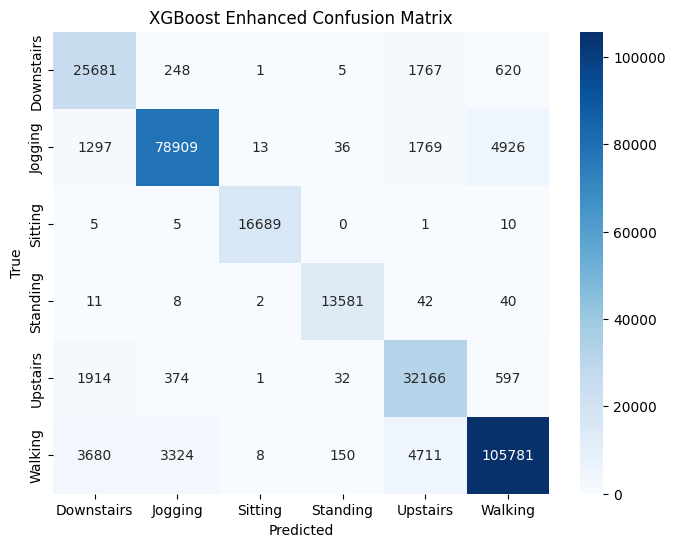

Generating Probability Distribution for top classes...


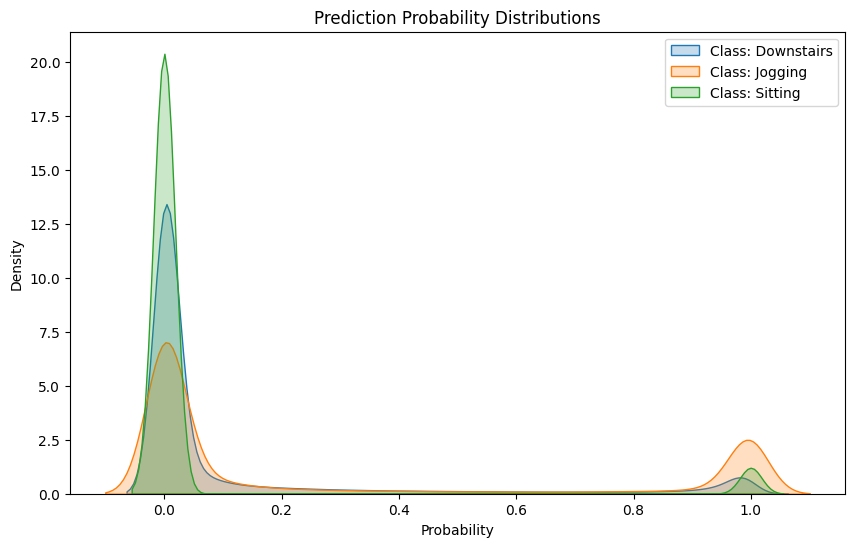

Generating Learning Curve...


KeyboardInterrupt: 

In [ ]:
if __name__ == "__main__":
    from sklearn.utils.class_weight import compute_sample_weight
    def get_dataset_path(filename="time_series_data_human_activities.csv", max_up=4):
        if os.path.exists(filename): return filename
        current_dir = os.getcwd()
        for _ in range(max_up):
            target = os.path.join(current_dir, filename)
            if os.path.exists(target): return target
            parent = os.path.dirname(current_dir)
            if current_dir == parent: break
            current_dir = parent
        return filename

    dataset_path = get_dataset_path()
    df_raw = load_data(dataset_path)

    if not df_raw.empty:
        
        df, le = preprocess_data(df_raw, sample_frac=1.0)
        X, y = extract_features(df)

        X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

        print("\n--- Processing Model Pipeline (Enhanced Features + Full Data) ---")
        x_train, x_test, y_train, y_test = split_and_balance_data(X, y, apply_smote=True)

        x_train_np = np.nan_to_num(x_train.to_numpy()).astype(np.float32)
        x_test_np = np.nan_to_num(x_test.to_numpy()).astype(np.float32)

        xgb_model = XGBClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=12,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method='hist',
            device='cuda',
            eval_metric='mlogloss',
            random_state=42
        )

        t0 = time.time()
        custom_weights = {0: 2.0, 4: 2.0, 1: 1.0, 2: 1.0, 3: 1.0, 5: 1.0}
        weights = compute_sample_weight(class_weight=custom_weights, y=y_train)

        xgb_model.fit(
            x_train_np, y_train,
            sample_weight=weights,
            eval_set=[(x_test_np, y_test)],
            verbose=False
        )
        print(f"XGBoost GPU Training Time: {time.time() - t0:.2f} seconds")

        evaluate_and_plot(xgb_model, "XGBoost Enhanced", x_test_np, y_test, le)
        plot_additional_diagnostics(xgb_model, x_train_np, y_train, x_test_np, y_test, le)

        print("\nPipeline execution complete.")

Displaying Diagnostic Graphs...


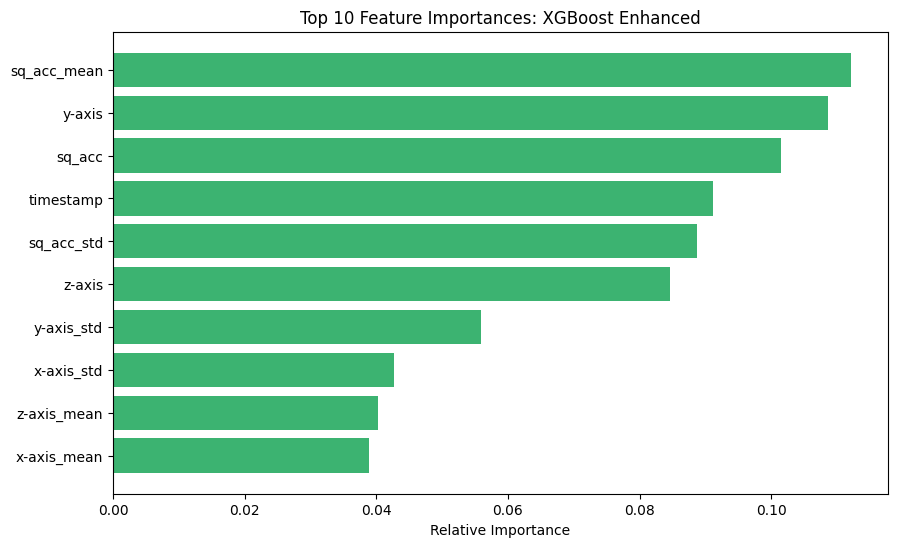

Generating learning curve for XGBoost Enhanced...


KeyboardInterrupt: 

In [63]:
# Re-plotting diagnostics using the existing model and data
print("Displaying Diagnostic Graphs...")

# 1. Feature Importance
plot_feature_importance(xgb_model, "XGBoost Enhanced", ["timestamp", "x-axis", "y-axis", "z-axis", "sq_acc", "x-axis_std", "x-axis_mean", "y-axis_std", "y-axis_mean", "z-axis_std", "z-axis_mean", "sq_acc_mean", "sq_acc_std", "x-axis_ema", "y-axis_ema", "z-axis_ema", "x-axis_fft", "y-axis_fft", "z-axis_fft", "sq_acc_fft"])

# 2. Learning Curve
plot_learning_curves(xgb_model, "XGBoost Enhanced", x_train_np, y_train)

# 3. Probability Distribution for top classes
y_probs = xgb_model.predict_proba(x_test_np)
plt.figure(figsize=(10, 6))
for i in range(min(3, len(le.classes_))):
    sns.kdeplot(y_probs[:, i], label=f'Class: {le.classes_[i]}', fill=True)
plt.title("Prediction Probability Distributions (XGBoost Enhanced)")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.legend()
plt.show()